In [17]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import json
from functions.plot_function import (plot_joint_trajectory,
                                     plot_joints_trajectory,
                                     plot_joint_index,
                                     animate_joint_index,)
from functions.load_data import load_data, load_multi_data
from functions.load_optitrack import (load_optitrack_csv, load_multi_optitrack,
                                      set_initial_position)
from sklearn.decomposition import PCA
import joblib
import csv
import pandas as pd

In [18]:
TRAJ_BASE = os.path.join(os.getcwd(), 'logs')
CASE, FOLDER, MODEL = 's20l','cot3','ff'
TRIALS = [0,1,2,3,4]
# TRIALS = [99,100,101]  # second batch, loaded separately below

TRIALS_EXTRA = [99,100,101]  # second batch, loaded separately below

norm_flat_ff = set_initial_position(load_multi_optitrack('flat',FOLDER,'ff',TRIALS,TRAJ_BASE))
norm_flat_hebb = set_initial_position(load_multi_optitrack('flat',FOLDER,'hebb',TRIALS,TRAJ_BASE))

norm_s20l_ff = set_initial_position(load_multi_optitrack('s20l',FOLDER,'ff',TRIALS,TRAJ_BASE))
norm_s20l_hebb = set_initial_position(load_multi_optitrack('s20l',FOLDER,'hebb',TRIALS,TRAJ_BASE))

norm_s10lr_ff = set_initial_position(load_multi_optitrack('s10lr',FOLDER,'ff',TRIALS,TRAJ_BASE))
norm_s10lr_hebb = set_initial_position(load_multi_optitrack('s10lr',FOLDER,'hebb',TRIALS,TRAJ_BASE))

# Extra batch (trials 99-101), kept separate so it doesn't overwrite the
norm_flat_ff_extra = set_initial_position(load_multi_optitrack('flat',FOLDER,'ff',TRIALS_EXTRA,TRAJ_BASE))
norm_flat_hebb_extra = set_initial_position(load_multi_optitrack('flat',FOLDER,'hebb',TRIALS_EXTRA,TRAJ_BASE))

norm_s20l_ff_extra = set_initial_position(load_multi_optitrack('s20l',FOLDER,'ff',TRIALS_EXTRA,TRAJ_BASE))
norm_s20l_hebb_extra = set_initial_position(load_multi_optitrack('s20l',FOLDER,'hebb',TRIALS_EXTRA,TRAJ_BASE))

norm_s10lr_ff_extra = set_initial_position(load_multi_optitrack('s10lr',FOLDER,'ff',TRIALS_EXTRA,TRAJ_BASE))
norm_s10lr_hebb_extra = set_initial_position(load_multi_optitrack('s10lr',FOLDER,'hebb',TRIALS_EXTRA,TRAJ_BASE))

In [19]:
TRIAL_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
INK, INK_MUTED, GRID = '#0b0b0b', '#52514e', '#e5e4e0'

def style_ax(ax):
    ax.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'): ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK_MUTED)
    ax.xaxis.label.set_color(INK_MUTED); ax.yaxis.label.set_color(INK_MUTED)

## Trajectory

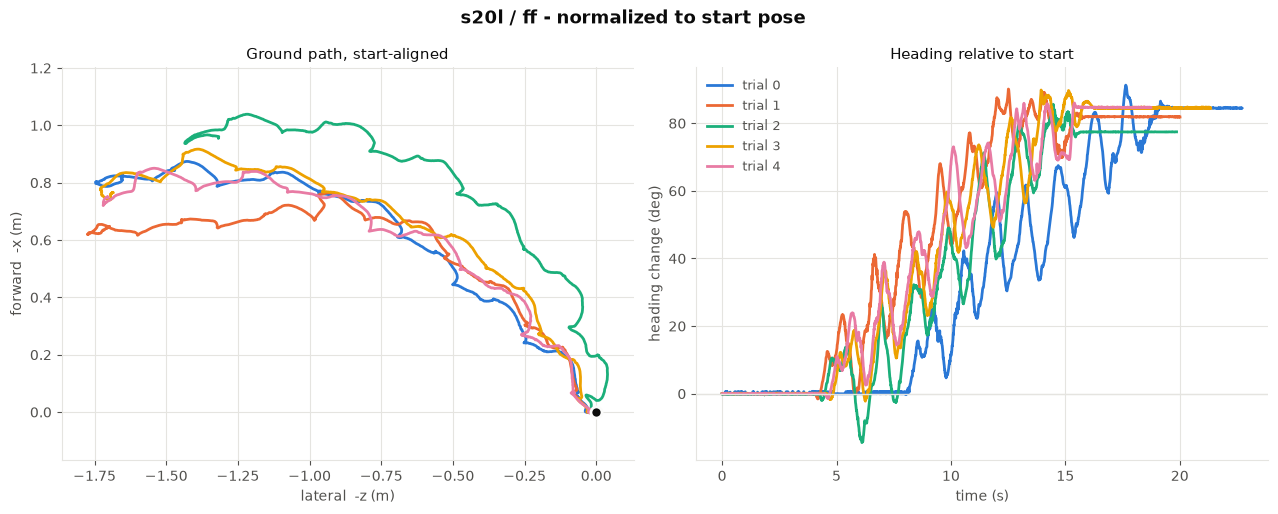

In [20]:
# Check: every trial now leaves the origin facing the same way
fig, (ax_p, ax_y) = plt.subplots(1, 2, figsize=(13, 5.2))
for i, df in enumerate(norm_s20l_ff):
    c = TRIAL_COLORS[i % len(TRIAL_COLORS)]
    ax_p.plot( -df['z_rel'],-df['x_rel'], color=c, lw=2, label=f'trial {TRIALS[i]}')
    ax_y.plot(df['time'], np.rad2deg(df['yaw_rel']), color=c, lw=2, label=f'trial {TRIALS[i]}')
ax_p.plot(0, 0, 'o', color=INK, ms=8, mec='#fcfcfb', mew=2, zorder=3)
# horizontal is -z_rel, vertical is -x_rel: robot heads up the page.
# right x up = +y, so this looks down on the floor and a real left
# turn curves left.
ax_p.set_xlabel('lateral  -z (m)'); ax_p.set_ylabel('forward  -x (m)')
ax_p.set_title('Ground path, start-aligned', color=INK, fontsize=11)
ax_p.set_aspect('equal', adjustable='datalim')

ax_y.axhline(0, color=GRID, lw=1)
ax_y.set_xlabel('time (s)'); ax_y.set_ylabel('heading change (deg)')
ax_y.set_title('Heading relative to start', color=INK, fontsize=11)

for ax in (ax_p, ax_y):
    style_ax(ax)

ax_y.legend(frameon=False, fontsize=9, labelcolor=INK_MUTED)
fig.suptitle(f'{CASE} / {MODEL} - normalized to start pose', fontsize=13,fontweight='bold', color=INK)
fig.tight_layout()

plt.show()

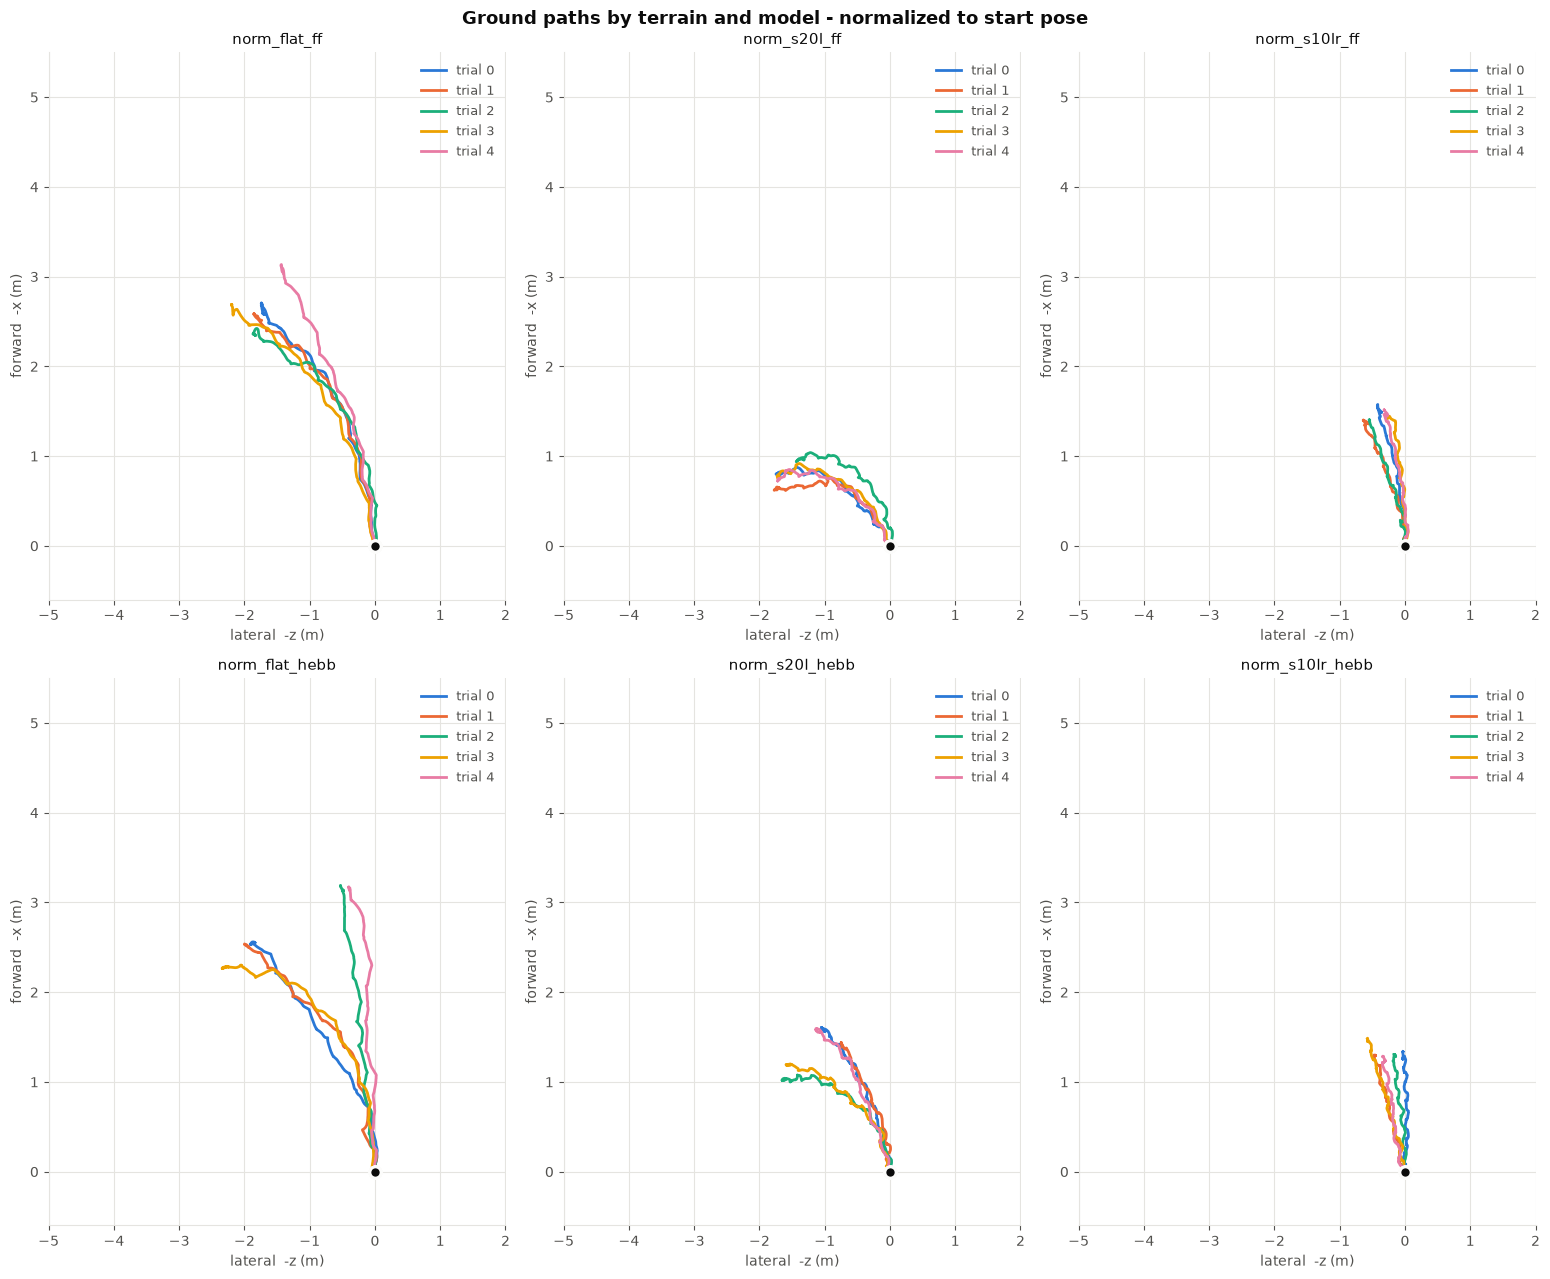

In [21]:
data = [norm_flat_ff , norm_s20l_ff , norm_s10lr_ff ,norm_flat_hebb, norm_s20l_hebb, norm_s10lr_hebb]
label = ['norm_flat_ff' , 'norm_s20l_ff' , 'norm_s10lr_ff' ,'norm_flat_hebb', 'norm_s20l_hebb', 'norm_s10lr_hebb']
fig, axs = plt.subplots(2, 3 ,figsize=( 15.6 , 13))

for i , ax in enumerate(axs.flatten()):
    for j, df in enumerate(data[i]):
        c = TRIAL_COLORS[j % len(TRIAL_COLORS)]
        ax.plot( -df['z_rel'],-df['x_rel'], color=c, lw=2, label=f'trial {TRIALS[j]}')
        ax.plot(0, 0, 'o', color=INK, ms=8, mec='#fcfcfb', mew=2, zorder=3)
    ax.plot(0, 0, 'o', color=INK, ms=8, mec='#fcfcfb', mew=2, zorder=3)
    ax.set_xlabel('lateral  -z (m)'); ax.set_ylabel('forward  -x (m)')
    ax.set_title(f'{label[i]}', color=INK, fontsize=11)
    # ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlim(-5.0, 2)
    ax.set_ylim(-0.6, 5.5)

    style_ax(ax)

    ax.legend(frameon=False, fontsize=9, labelcolor=INK_MUTED)
fig.suptitle('Ground paths by terrain and model - normalized to start pose',
             fontsize=13, fontweight='bold', color=INK)
fig.tight_layout()
plt.show()
    
    

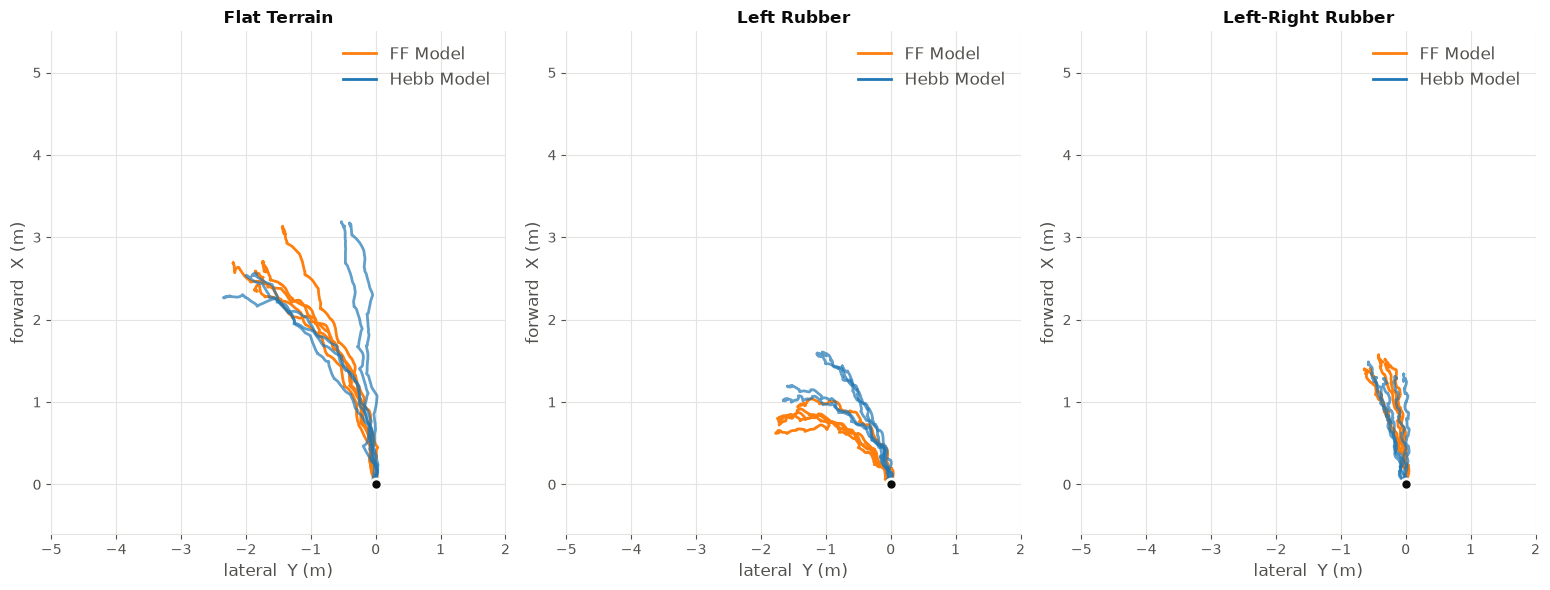

In [22]:
# Group your data into FF and Hebb lists, matching terrain order
data_ff = [norm_flat_ff, norm_s20l_ff, norm_s10lr_ff]
data_hebb = [norm_flat_hebb, norm_s20l_hebb, norm_s10lr_hebb]
# Subplot titles (one for each terrain)
terrain_labels = ['Flat Terrain', 'Left Rubber', 'Left-Right Rubber']

# --- DEFINITIONS FOR COLOR SEPARATION ---
COLOR_FF =   'tab:orange' # Primary color for all Feedforward models (Solid Blue)
COLOR_HEBB = 'tab:blue' # Primary color for all Hebb models (Solid Orange)

fig, axs = plt.subplots(1, 3, figsize=(15.6, 6))
for i, ax in enumerate(axs.flatten()):

    # --- PLOT THE DATA ---
    for j, df in enumerate(data_ff[i]):
        ax.plot(-df['z_rel'], -df['x_rel'],
                color=COLOR_FF,
                linestyle='-', 
                lw=2,
                alpha=1.0) 

    # 2. Plot the HEBB data (Solid lines, Orange)
    for j, df in enumerate(data_hebb[i]):
        ax.plot(-df['z_rel'], -df['x_rel'],
                color=COLOR_HEBB,
                linestyle='-',  
                lw=2,
                alpha=0.7) 

    # --- FORMAT THE SUBPLOT ---

    # Plot origin dot once per subplot
    ax.plot(0, 0, 'o', color=INK, ms=8, mec='#fcfcfb', mew=2, zorder=3)

    # Labels and Title
    ax.set_xlabel('lateral  Y (m)' , fontsize=12)
    ax.set_ylabel('forward  X (m)'  , fontsize=12)
    ax.set_title(terrain_labels[i], color=INK, fontsize=12, fontweight='bold')

    # Shared limits for direct comparison
    ax.set_xlim(-5.0, 2.0)
    ax.set_ylim(-0.6, 5.5)

    style_ax(ax)

    # --- CUSTOM LEGEND ---
    ax.plot([], [], color=COLOR_FF, ls='-', lw=2, label='FF Model')
    ax.plot([], [], color=COLOR_HEBB, ls='-', lw=2, label='Hebb Model')
    ax.legend(frameon=False, fontsize=12, labelcolor=INK_MUTED, loc='upper right')

# Global Figure Formatting
# fig.suptitle('Ground paths by terrain: FF Model (Blue) vs Hebb Model (Orange)', fontsize=14, fontweight='bold', color=INK, y=1.05)

fig.tight_layout()
plt.show()

### FF vs Hebb, including Trials 99-101

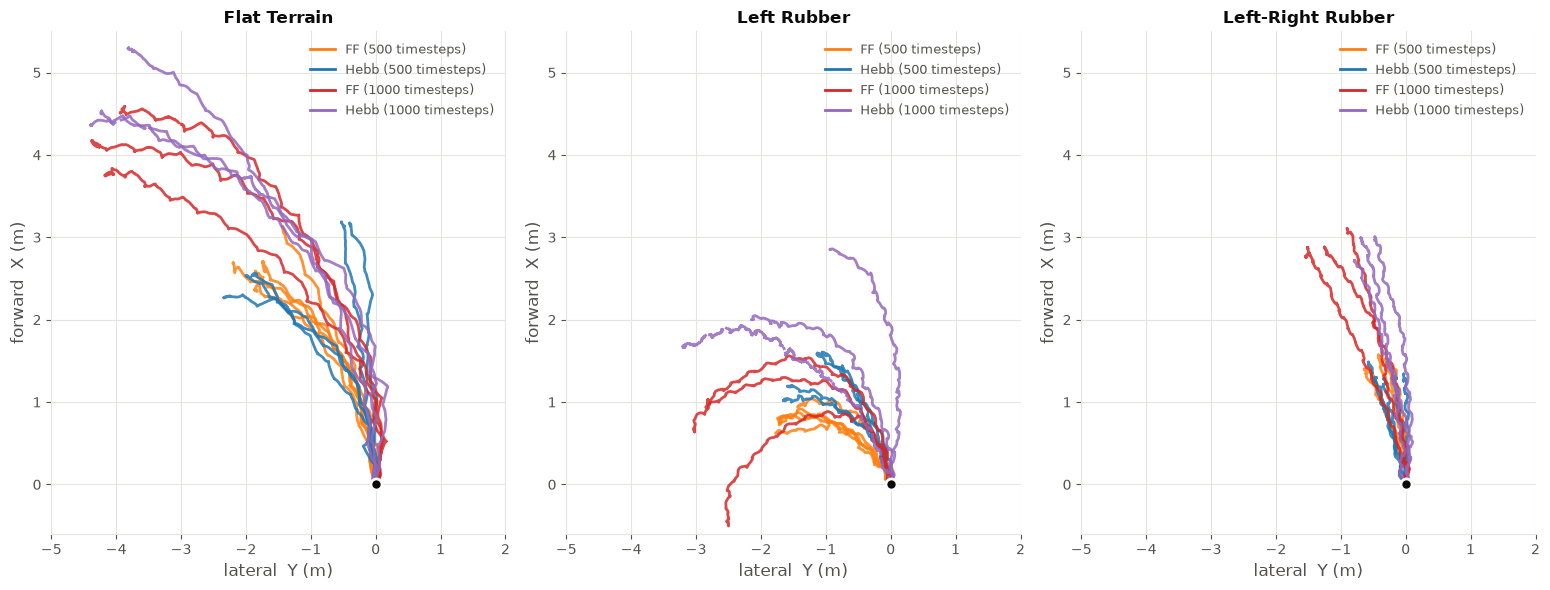

In [23]:
# Same terrain-panel layout as above, but overlaying both trial batches:
# trials 0-4 (primary) and trials 99-101 (extra), each combination of
# model x batch gets its own color/legend entry.
terrain_labels = ['Flat Terrain', 'Left Rubber', 'Left-Right Rubber']

groups = [
    {'label': 'FF (500 timesteps)',      'color': 'tab:orange', 'data': [norm_flat_ff,       norm_s20l_ff,       norm_s10lr_ff]},
    {'label': 'Hebb (500 timesteps)',    'color': 'tab:blue',   'data': [norm_flat_hebb,     norm_s20l_hebb,     norm_s10lr_hebb]},
    {'label': 'FF (1000 timesteps)',   'color': 'tab:red',    'data': [norm_flat_ff_extra, norm_s20l_ff_extra, norm_s10lr_ff_extra]},
    {'label': 'Hebb (1000 timesteps)', 'color': 'tab:purple', 'data': [norm_flat_hebb_extra, norm_s20l_hebb_extra, norm_s10lr_hebb_extra]},
]

fig, axs = plt.subplots(1, 3, figsize=(15.6, 6))
for i, ax in enumerate(axs):
    for g in groups:
        for df in g['data'][i]:
            ax.plot(-df['z_rel'], -df['x_rel'], color=g['color'], lw=2, alpha=0.85)

    ax.plot(0, 0, 'o', color=INK, ms=8, mec='#fcfcfb', mew=2, zorder=3)
    ax.set_xlabel('lateral  Y (m)', fontsize=12)
    ax.set_ylabel('forward  X (m)', fontsize=12)
    ax.set_title(terrain_labels[i], color=INK, fontsize=12, fontweight='bold')
    ax.set_xlim(-5.0, 2.0)
    ax.set_ylim(-0.6, 5.5)

    style_ax(ax)

    for g in groups:
        ax.plot([], [], color=g['color'], ls='-', lw=2, label=g['label'])
    ax.legend(frameon=False, fontsize=9, labelcolor=INK_MUTED, loc='upper right')
    # fig.savefig("traj.png", dpi=600, bbox_inches="tight")
fig.tight_layout()
plt.show()

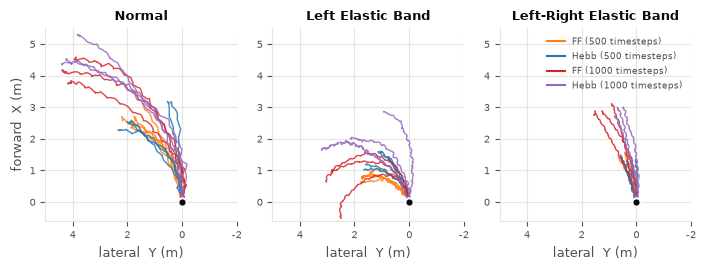

In [24]:
# Same terrain-panel layout as above, but overlaying both trial batches:
# trials 0-4 (primary) and trials 99-101 (extra), each combination of
from matplotlib.ticker import FuncFormatter

# model x batch gets its own color/legend entry.
terrain_labels = ['Normal', 'Left Elastic Band', 'Left-Right Elastic Band']
sign_flip_formatter = FuncFormatter(lambda x, pos: f"{0 if x == 0 else -x:g}")
groups = [
    {'label': 'FF (500 timesteps)',    'color': 'tab:orange', 'data': [norm_flat_ff,       norm_s20l_ff,       norm_s10lr_ff]},
    {'label': 'Hebb (500 timesteps)',  'color': 'tab:blue',   'data': [norm_flat_hebb,     norm_s20l_hebb,     norm_s10lr_hebb]},
    {'label': 'FF (1000 timesteps)',   'color': 'tab:red',    'data': [norm_flat_ff_extra, norm_s20l_ff_extra, norm_s10lr_ff_extra]},
    {'label': 'Hebb (1000 timesteps)', 'color': 'tab:purple', 'data': [norm_flat_hebb_extra, norm_s20l_hebb_extra, norm_s10lr_hebb_extra]},
]

IEEE_TWO_COL_WIDTH = 7.16  # inches, full double-column width (IEEEtran \textwidth)

fig, axs = plt.subplots(1, 3, figsize=(IEEE_TWO_COL_WIDTH, 2.8))
for i, ax in enumerate(axs):
    for g in groups:
        for df in g['data'][i]:
            ax.plot(-df['z_rel'], -df['x_rel'], color=g['color'], lw=1.0, alpha=0.85)

    ax.plot(0, 0, 'o', color=INK, ms=6, mec='#fcfcfb', mew=1.5, zorder=3)
    if(i == 0):
        ax.set_ylabel('forward  X (m)', fontsize=9)
    ax.set_xlabel('lateral  Y (m)', fontsize=9)
    ax.set_title(terrain_labels[i], color=INK, fontsize=9, fontweight='bold')
    ax.set_xlim(-5.0, 2.0)
    ax.set_ylim(-0.6, 5.5)
    ax.xaxis.set_major_formatter(sign_flip_formatter)

    style_ax(ax)
    ax.tick_params(labelsize=7)

    for g in groups:
        ax.plot([], [], color=g['color'], ls='-', lw=1.5, label=g['label'])
    if i == 2:
        ax.legend(frameon=False, fontsize=6.5, labelcolor=INK_MUTED, loc='upper right')
    fig.savefig("traj.png", dpi=600, bbox_inches="tight")
fig.tight_layout()
plt.show()

In [25]:
runs = {
    'flat_ff':    norm_flat_ff,   'flat_hebb':   norm_flat_hebb,
    's20l_ff':    norm_s20l_ff,   's20l_hebb':   norm_s20l_hebb,
    's10lr_ff':   norm_s10lr_ff,  's10lr_hebb':  norm_s10lr_hebb,
}

max_distance = {name: np.array([np.hypot(d['x_rel'], d['z_rel']).max() for d in takes])
                for name, takes in runs.items()}

for name, v in max_distance.items():
    print(f'{name:12} n={len(v)}  ' + '  '.join(f'{q:.2f}' for q in v))

flat_ff      n=5  3.22  3.18  3.03  3.47  3.45
flat_hebb    n=5  3.18  3.23  3.23  3.26  3.20
s20l_ff      n=5  1.92  1.88  1.72  1.90  1.87
s20l_hebb    n=5  1.92  1.62  1.94  1.99  1.96
s10lr_ff     n=5  1.63  1.54  1.51  1.48  1.55
s10lr_hebb   n=5  1.34  1.38  1.32  1.59  1.33


In [26]:
from scipy import stats
def mean_ci95(x):
    x, n, m = np.asarray(x) , len(x) , x.mean()
    sem = x.std(ddof=1) / np.sqrt(n)
    h = sem * stats.t.ppf(0.975, n - 1)  # 95% CI half-width, n=10 -> t~2.26
    return m, h

In [27]:
BAR_COLORS = {'Hebbian': '#2a78d6', 'Feedforward': '#eb6834'}
DOT_COLORS = {'Hebbian': "#2d2ad6", 'Feedforward': "#e70e06"}

def plot_distance_bars(groups, case, ylabel, title, mean_pos=0.1):
    n_trials = len(next(iter(groups.values()))[0])
    x = np.arange(len(case))
    width = 0.35

    fig, ax = plt.subplots(layout='constrained')
    for i, (label, arrs) in enumerate(groups.items()):
        means, halfwidths = zip(*(mean_ci95(a) for a in arrs))
        offset = (i - (len(groups) - 1) / 2) * width
        ax.bar(x + offset, means, width, label=label, color=BAR_COLORS[label])

        for xi, m, h in zip(x + offset, means, halfwidths):
            # ax.text(xi, m + h, f'{m:.2f}', ha='center', va='bottom', fontsize=10)
            ax.text(xi, mean_pos, f'{m:.2f}', ha='center', va='bottom', fontsize=10)

        for xi, a in zip(x + offset, arrs):
            ax.scatter(np.full(len(a), xi), a, color=DOT_COLORS[label],
                       alpha=0.9, s=40, edgecolors='white', linewidth=1.2, zorder=3)

    ax.set_xticks(x, case)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title} (mean ± 95% CI, n={n_trials} trials)')
    style_ax(ax)
    # headroom so the value labels clear the legend
    top = max(m + h for arrs in groups.values() for m, h in (mean_ci95(a) for a in arrs))
    ax.set_ylim(0, top * 1.22)
    ax.legend(loc='upper left', ncols=2, frameon=False, labelcolor=INK_MUTED)

    plt.show()
    return fig, ax

## Distance

### Final Point

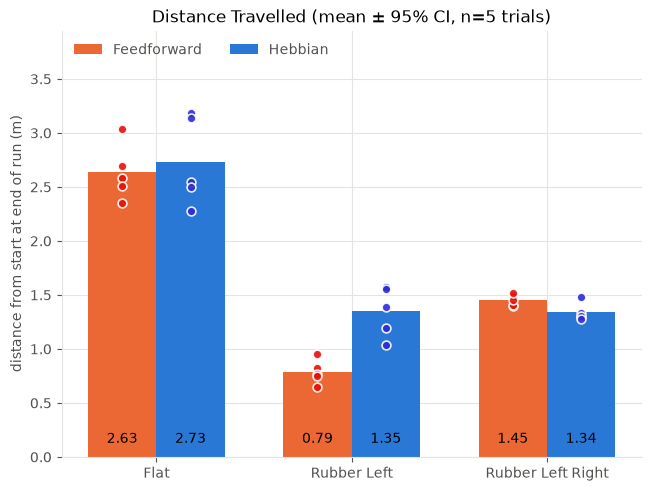

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Distance Travelled (mean ± 95% CI, n=5 trials)'}, ylabel='distance from start at end of run (m)'>)

In [28]:
last_distance = {name: np.array([-d['x_rel'].iloc[-1] for d in takes])
                  for name, takes in runs.items()}

case = ("Flat",  "Rubber Left" , "Rubber Left Right")
groups = {
    'Feedforward': [last_distance["flat_ff"],   last_distance["s20l_ff"],   last_distance["s10lr_ff"]],
    'Hebbian':     [last_distance["flat_hebb"], last_distance["s20l_hebb"], last_distance["s10lr_hebb"]],
}

plot_distance_bars(groups, case, 'distance from start at end of run (m)', 'Distance Travelled')

### Max Distance


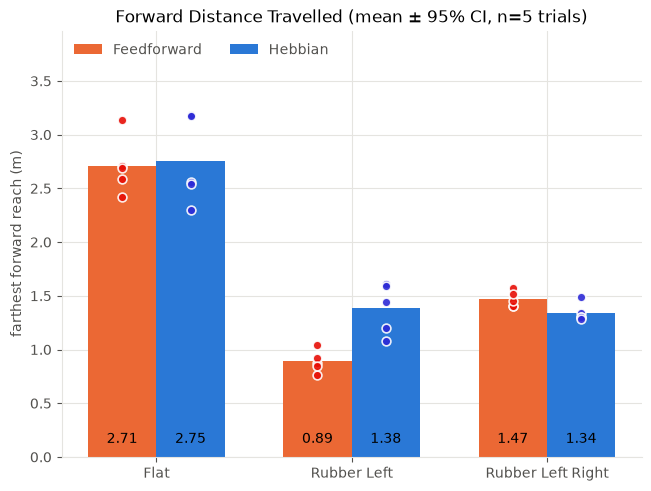

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Forward Distance Travelled (mean ± 95% CI, n=5 trials)'}, ylabel='farthest forward reach (m)'>)

In [29]:
# Farthest forward (x-only) reach per trial: x_rel starts at 0 and goes more
# negative as the robot moves forward, so the farthest forward point is
# x_rel.min(), not .max() (.max() is ~0, the starting point).
max_forward_distance = {
    name: np.array([-d['x_rel'].min() for d in takes])
    for name, takes in runs.items()
}

case = ("Flat",  "Rubber Left" , "Rubber Left Right")
groups = {
    'Feedforward': [max_forward_distance["flat_ff"],   max_forward_distance["s20l_ff"],   max_forward_distance["s10lr_ff"]],
    'Hebbian':     [max_forward_distance["flat_hebb"], max_forward_distance["s20l_hebb"], max_forward_distance["s10lr_hebb"]],
}

plot_distance_bars(groups, case, 'farthest forward reach (m)', 'Forward Distance Travelled')

## Velocity


In [30]:
# Logs include a stationary period before/after the walk (position flat,
# speed at noise level), so a plain mean of instantaneous speed would be
# dragged down by however long that padding happens to be. Instead: find the
# window where smoothed ground speed is above a noise threshold, and take
# average velocity as displacement / elapsed time over just that window.
def moving_mask(df, speed_threshold=0.05, smooth_window=21):
    dt = df['time'].diff()
    vx = df['x_rel'].diff() / dt
    vz = df['z_rel'].diff() / dt
    speed = np.hypot(vx, vz)
    speed_smooth = speed.rolling(smooth_window, center=True, min_periods=1).mean()
    return speed_smooth > speed_threshold

def avg_forward_velocity(df, speed_threshold=0.05, smooth_window=21):
    idx = np.flatnonzero(moving_mask(df, speed_threshold, smooth_window).to_numpy())
    if len(idx) < 2:
        return 0.0
    i0, i1 = idx[0], idx[-1]
    dx = -(df['x_rel'].iloc[i1] - df['x_rel'].iloc[i0])  # forward = -x_rel
    dt = df['time'].iloc[i1] - df['time'].iloc[i0]
    return dx / dt

In [31]:
avg_velocity = {name: np.array([avg_forward_velocity(d) for d in takes])
                 for name, takes in runs.items()}

for name, v in avg_velocity.items():
    print(f'{name:12} n={len(v)}  ' + '  '.join(f'{q:.3f}' for q in v))

flat_ff      n=5  0.210  0.215  0.168  0.234  0.267
flat_hebb    n=5  0.165  0.217  0.278  0.142  0.276
s20l_ff      n=5  0.054  0.056  0.086  0.069  0.070
s20l_hebb    n=5  0.134  0.119  0.090  0.058  0.134
s10lr_ff     n=5  0.136  0.125  0.132  0.136  0.138
s10lr_hebb   n=5  0.071  0.071  0.095  0.107  0.111


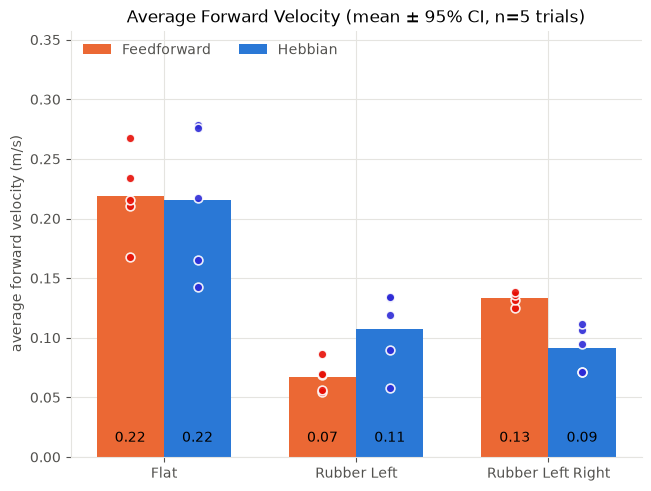

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Average Forward Velocity (mean ± 95% CI, n=5 trials)'}, ylabel='average forward velocity (m/s)'>)

In [32]:
case = ("Flat",  "Rubber Left" , "Rubber Left Right")
groups = {
    'Feedforward': [avg_velocity["flat_ff"],   avg_velocity["s20l_ff"],   avg_velocity["s10lr_ff"]],
    'Hebbian':     [avg_velocity["flat_hebb"], avg_velocity["s20l_hebb"], avg_velocity["s10lr_hebb"]],
}

plot_distance_bars(groups, case, 'average forward velocity (m/s)', 'Average Forward Velocity', mean_pos=0.01)

## Heading

In [33]:
DECIMATE = 2      # takes are 100 Hz; every 2nd frame -> 50 Hz

# Same case/model order as `runs`, labeled like optitrack_reward.ipynb so
# _terrains() below can parse "norm_<terrain>_<model>" back apart.
label = [f'norm_{name}' for name in runs]
data = [runs[name] for name in runs]

# [(time, yaw_rel)] per trial, per condition - decimated, no smoothing or trimming.
yaw = [[(df['time'].to_numpy(float)[::DECIMATE], df['yaw_rel'].to_numpy(float)[::DECIMATE])
        for df in takes]
       for takes in data]

In [34]:
MODEL_COLORS = {'hebb': '#2a78d6', 'ff': '#eb6834'}

def _style(ax, ylabel, title, ylim):
    ax.axhline(0, color=GRID, lw=1)
    ax.set_xlabel('time (s)'); ax.set_ylabel(ylabel)
    ax.set_title(title, color=INK, fontsize=11)
    if ylim: ax.set_ylim(*ylim)
    style_ax(ax)
    ax.legend(frameon=False, fontsize=9, labelcolor=INK_MUTED)

def _terrains(names):
    """Group the entries of `label` by terrain, keeping the order they appear in.
    'norm_s20l_hebb' -> terrain 's20l', model 'hebb', so the layout follows
    whichever four or six conditions `data` currently holds."""
    order, groups = [], {}
    for i, n in enumerate(names):
        terrain, _, model = n.replace('norm_', '').rpartition('_')
        groups.setdefault(terrain, {})[model] = i
        if terrain not in order: order.append(terrain)
    return [(t, groups[t]) for t in order]

def _summary(runs_, stat):
    """stat='mean' for a level, 'final' for where a cumulative curve ends."""
    if stat == 'final':
        return np.nanmean([y[-1] for _, y in runs_]), 'final '
    return np.nanmean([np.nanmean(y) for _, y in runs_]), 'mean '

def _panel_order(n, layout):
    """Panel index for each cell of the grid, None where a cell stays empty.
    'model' gives one row per model, ff on top, one column per terrain.
    'data' fills two rows in the order `data` happens to be written."""
    if layout == 'model':
        groups = _terrains(label)
        models = list(dict.fromkeys(m for _, g in groups for m in g))
        order = [g.get(m) for m in models for _, g in groups]
        return order, len(models), len(groups)
    ncols = -(-n // 2)
    return list(range(n)) + [None] * (2 * ncols - n), 2, ncols

def grid_panels(series, ylabel, suptitle, ylim=None, fmt='{:.2f}', stat='mean',
                layout='data'):
    """One panel per condition, one line per trial, in the trajectory-plot style."""
    order, nrows, ncols = _panel_order(len(series), layout)
    fig, axs = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.5 * nrows),
                            sharex=True, sharey=True, squeeze=False)
    for i, ax in zip(order, axs.flatten()):
        if i is None:
            ax.set_visible(False); continue
        for j, (t, y) in enumerate(series[i]):
            ax.plot(t, y, color=TRIAL_COLORS[j % len(TRIAL_COLORS)], lw=1.6,
                    label=f'trial {TRIALS[j]}')
        # trial-averaged level, so panels can be read against each other
        mbar, tag = _summary(series[i], stat)
        ax.axhline(mbar, color=INK, lw=1.2, ls='--', zorder=4)
        ax.text(0.98, 0.04, tag + fmt.format(mbar), transform=ax.transAxes,
                ha='right', va='bottom', fontsize=9, color=INK)
        _style(ax, ylabel, label[i], ylim)
    fig.suptitle(suptitle, fontsize=13, fontweight='bold', color=INK)
    fig.tight_layout(); plt.show()

def mean_band(runs_, dt=0.02):
    """Trials differ in length, so each is resampled onto a common grid that
    stops at the shortest take rather than being padded. Dropped frames are
    interpolated across rather than carried through: np.interp would spread a
    single NaN over the whole mean."""
    grid = np.arange(0, min(t[-1] for t, _ in runs_), dt)
    stack = np.vstack([np.interp(grid, t[np.isfinite(y)], y[np.isfinite(y)])
                       for t, y in runs_])
    return grid, stack.mean(0), stack.std(0, ddof=1)

def compare_models(series, ylabel, suptitle, ylim=None, fmt='{:.2f}', stat='mean',clip=None):
    """ff against hebb on one axis per terrain, mean +/- 1 sd across trials."""
    groups = _terrains(label)
    fig, axs = plt.subplots(1, len(groups), figsize=(6.5 * len(groups), 5.2),
                            sharey=True, squeeze=False)
    for ax, (name, models) in zip(axs.flatten(), groups):
        for mdl, i in models.items():
            g, m, sd = mean_band(series[i])
            c = MODEL_COLORS.get(mdl, INK_MUTED)
            if clip == None:
                ax.fill_between(g, m - sd, m + sd, color=c, alpha=0.18, lw=0)
            else:
                ax.fill_between(g, np.clip(m - sd , a_min=clip[0] , a_max=clip[1]), np.clip(m + sd , a_min=clip[0] , a_max=clip[1]), color=c, alpha=0.18, lw=0)

            v = m[-1] if stat == 'final' else m.mean()
            ax.plot(g, m, color=c, lw=2.2,
                    label=f'{mdl}  (' + fmt.format(v) + ')')
        _style(ax, ylabel, name, ylim)
    fig.suptitle(suptitle, fontsize=13, fontweight='bold', color=INK)
    fig.tight_layout(); plt.show()

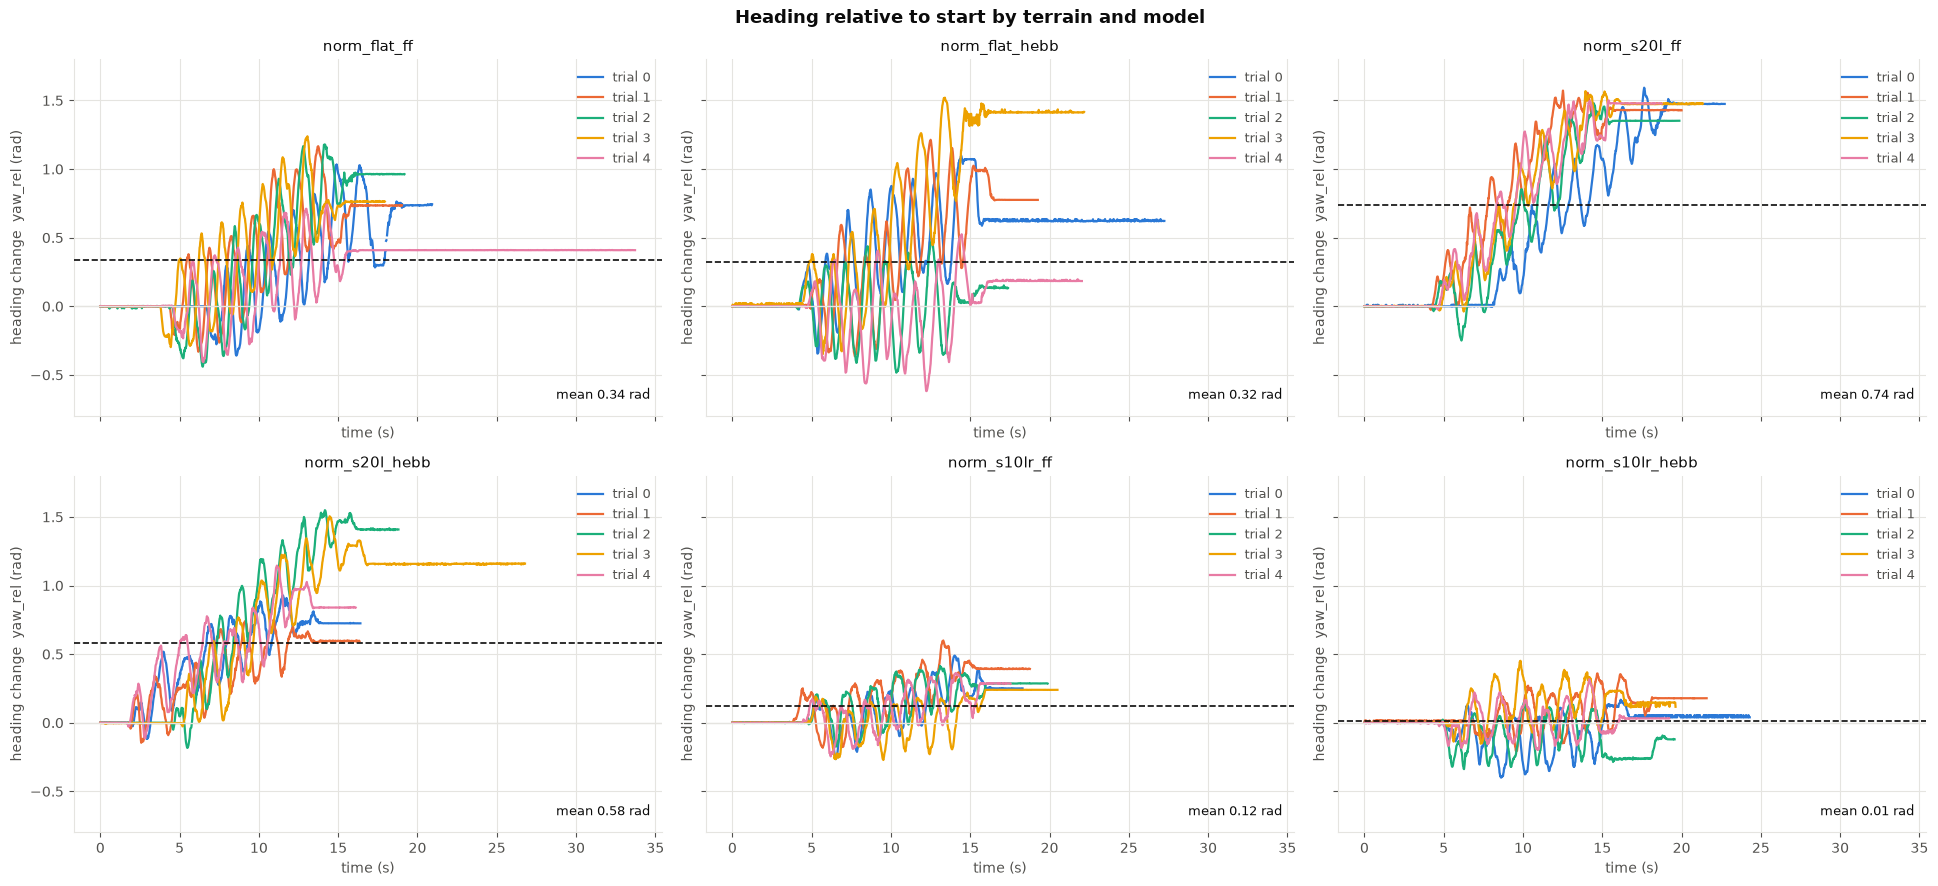

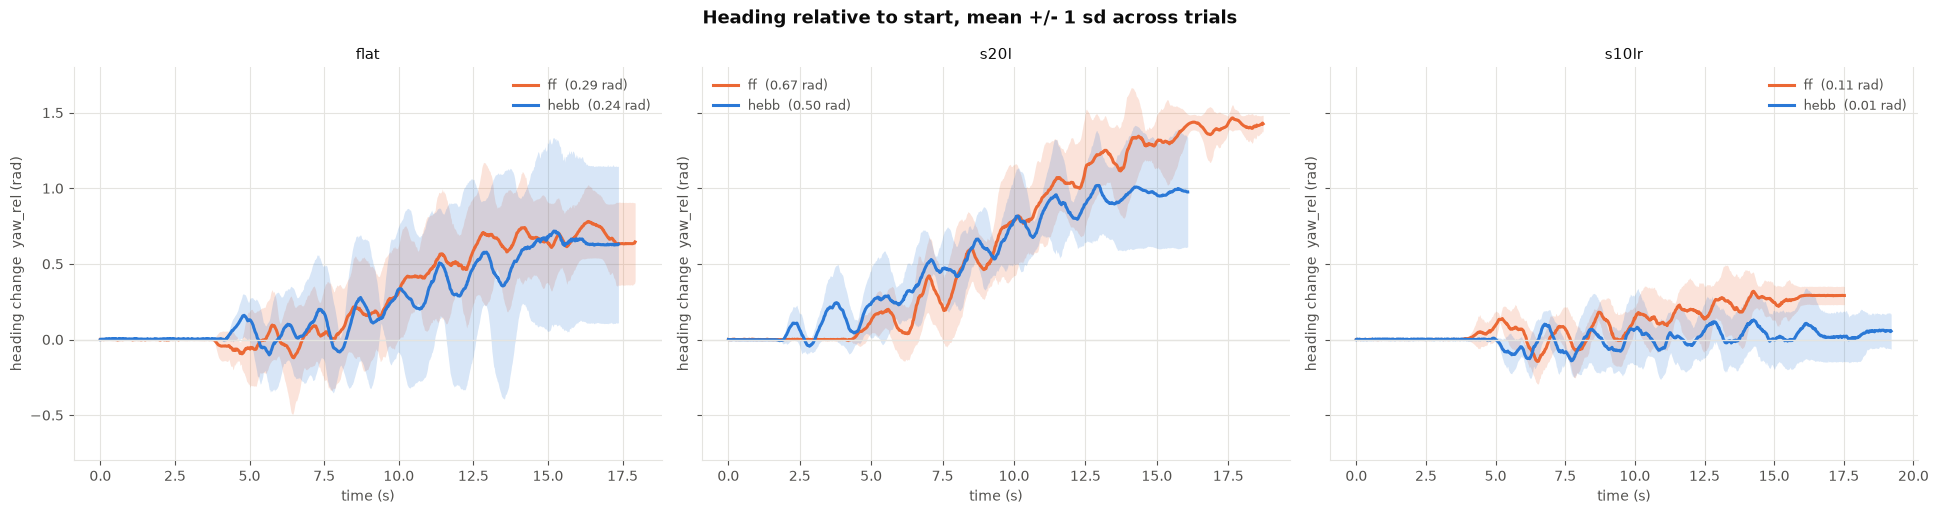

In [35]:
# Radians, not degrees: yaw_rel is 0 at the start of every take, so a flat line
# is a straight walk and the sign says which way the robot drifted.
Y_LABEL, Y_LIM = 'heading change  yaw_rel (rad)', (-0.8, 1.8)
grid_panels(yaw, Y_LABEL, 'Heading relative to start by terrain and model',
            Y_LIM, fmt='{:.2f} rad')
compare_models(yaw, Y_LABEL, 'Heading relative to start, mean +/- 1 sd across trials',
               Y_LIM, fmt='{:.2f} rad')

## Upright

In [36]:
from scipy.spatial.transform import Rotation as Rot

def upright(df):
    """Body vertical axis projected on the world vertical axis: 1.0 is
    perfectly level and the value is cos(tilt) in general. Motive exports
    Euler XYZ in degrees with Y up; read as intrinsic 'XYZ', column 1 of the
    rotation matrix is the body +Y axis in world coordinates, and its Y
    component is the projection on world up. Absolute, never start-referenced."""
    t = df['time'].to_numpy(float)
    e = np.deg2rad(df[['rot_x', 'rot_y', 'rot_z']].to_numpy(float))
    ok = np.isfinite(e).all(1)          # dropped frames stay NaN, not 0
    u = np.full(len(e), np.nan)
    u[ok] = Rot.from_euler('XYZ', e[ok]).as_matrix()[:, 1, 1]
    return t, u

# [(time, upright)] per trial, per condition - raw, no smoothing or trimming.
upr = [[upright(df) for df in takes] for takes in data]

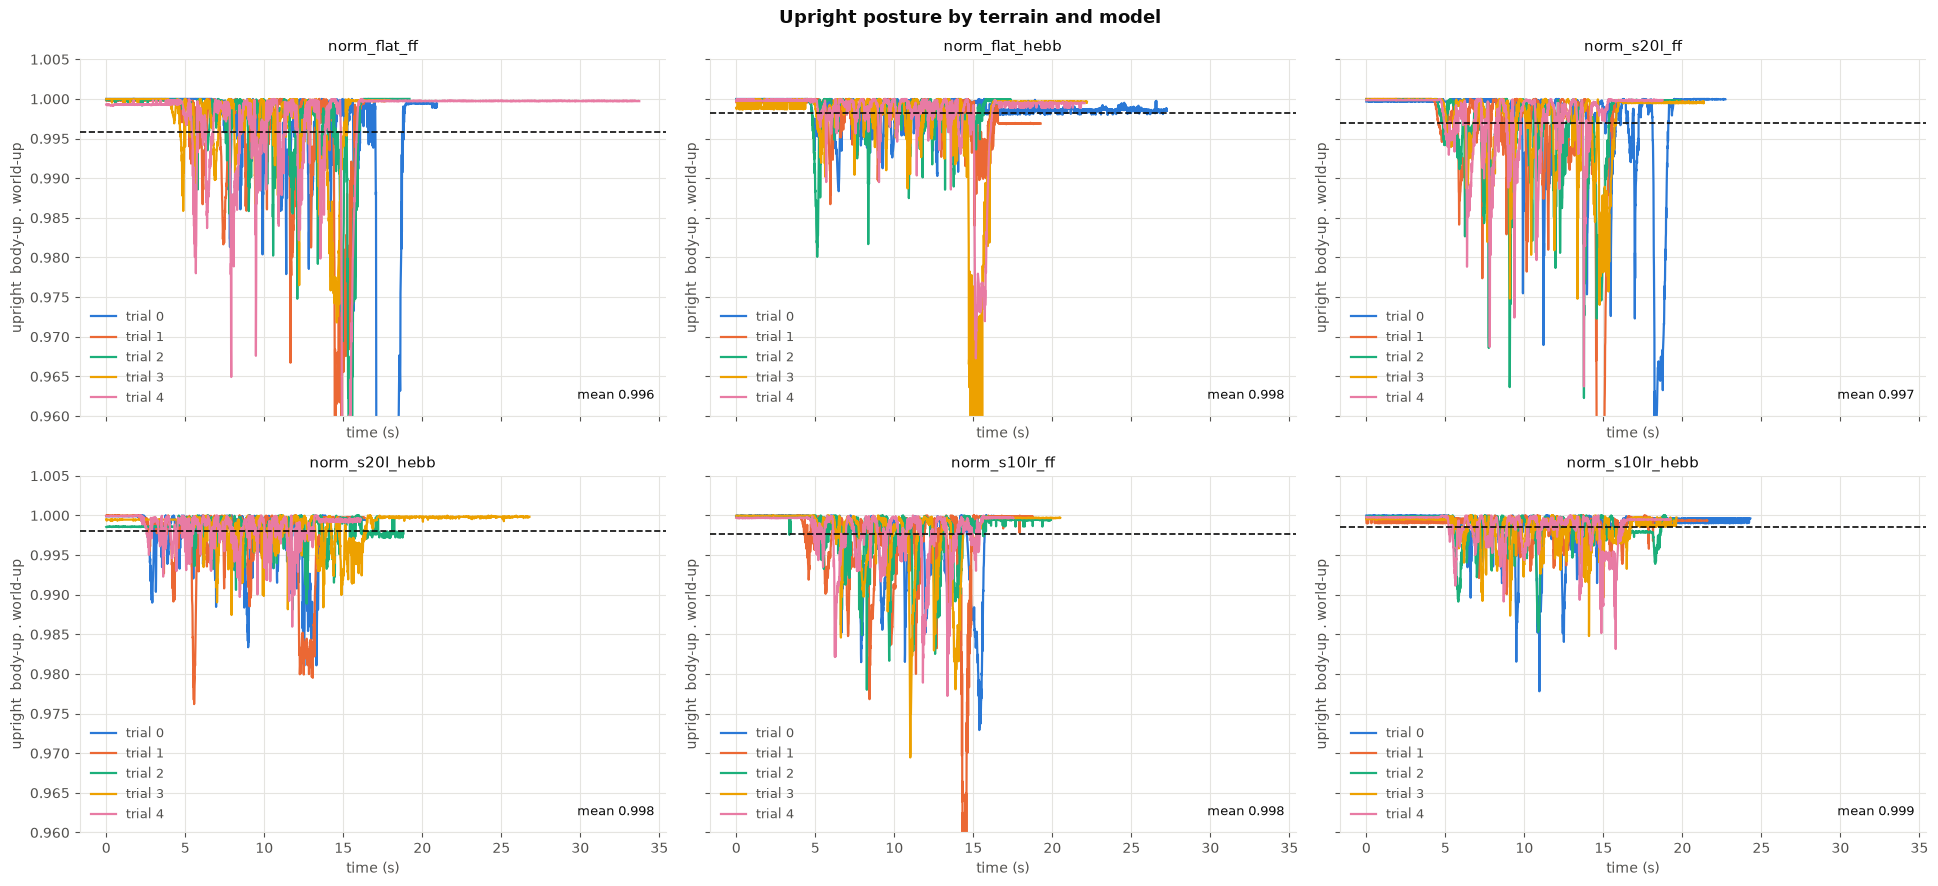

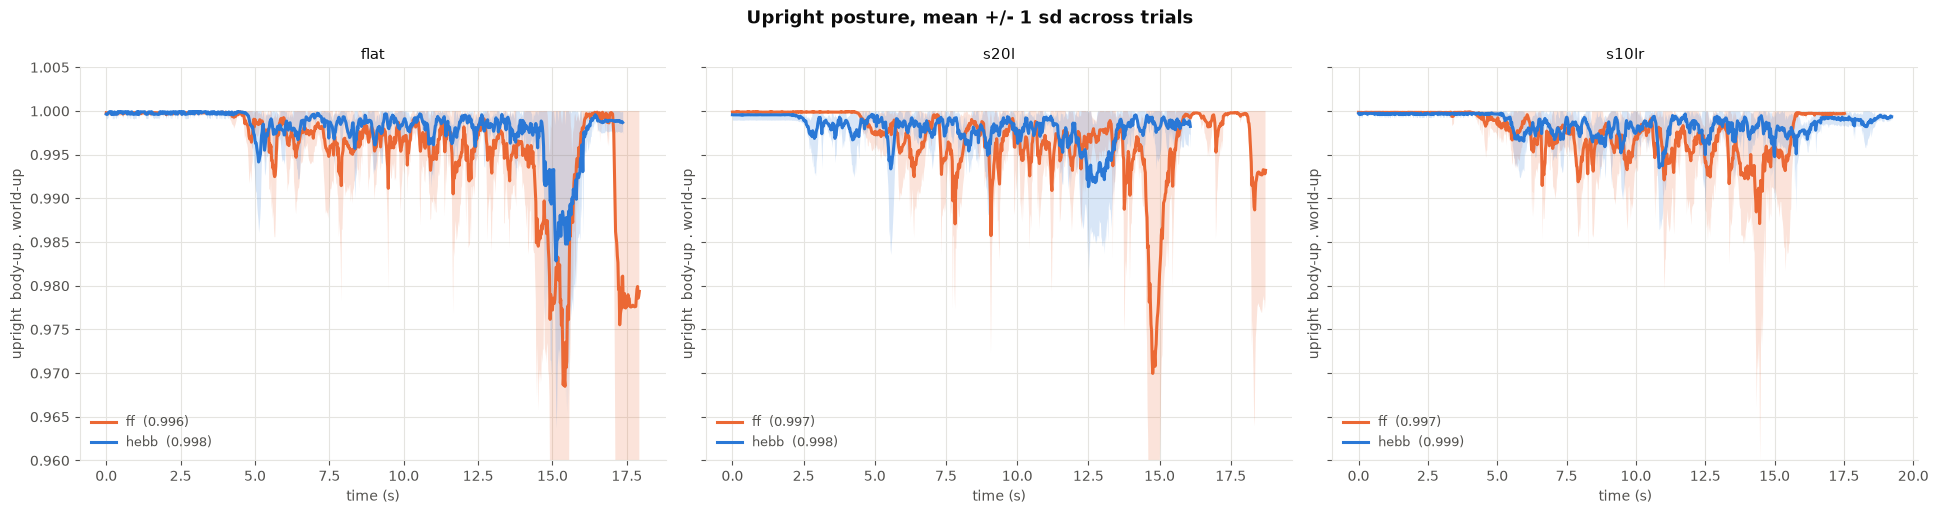

In [37]:
# Upright term: body up axis dotted with world up, so 1.0 is level and the drop
# below 1 is the cosine of the tilt angle. Absolute, never start-referenced.
U_LABEL, U_LIM = 'upright  body-up . world-up', (0.96, 1.005)
grid_panels(upr, U_LABEL, 'Upright posture by terrain and model',
            U_LIM, fmt='{:.3f}')
compare_models(upr, U_LABEL, 'Upright posture, mean +/- 1 sd across trials',
               U_LIM, fmt='{:.3f}',clip=[-1,1])

## Current

In [38]:
# Raw servo logs (500-step control buffer, not the optitrack log), keyed the
# same as `runs` so ordering matches `label`/`data`.
RAW_DATA_BASE = os.path.join(os.getcwd(), 'logs')
RAW_TO_CURRENT = 2.69  # mA per raw unit

raw = {}
for name in runs:
    case, model = name.rsplit('_', 1)
    raw[name] = load_multi_data(case, FOLDER, model, TRIALS, RAW_DATA_BASE)

def total_current(trial, decimate=DECIMATE):
    """Total unsigned current draw across all joints, Amps. Summed like the
    CoT power term, so a limb fighting another limb still counts as effort
    even though the signed currents could cancel."""
    d = np.array(trial['dt'])[::decimate]
    t = np.concatenate(([0.0], np.cumsum(d)[:-1]))
    cur = np.array(trial['current'])[::decimate] * RAW_TO_CURRENT / 1000.0  # A
    return t, np.sum(np.abs(cur), axis=1)

# [(time, total_current)] per trial, per condition.
cur = [[total_current(trial) for trial in raw[name]] for name in runs]

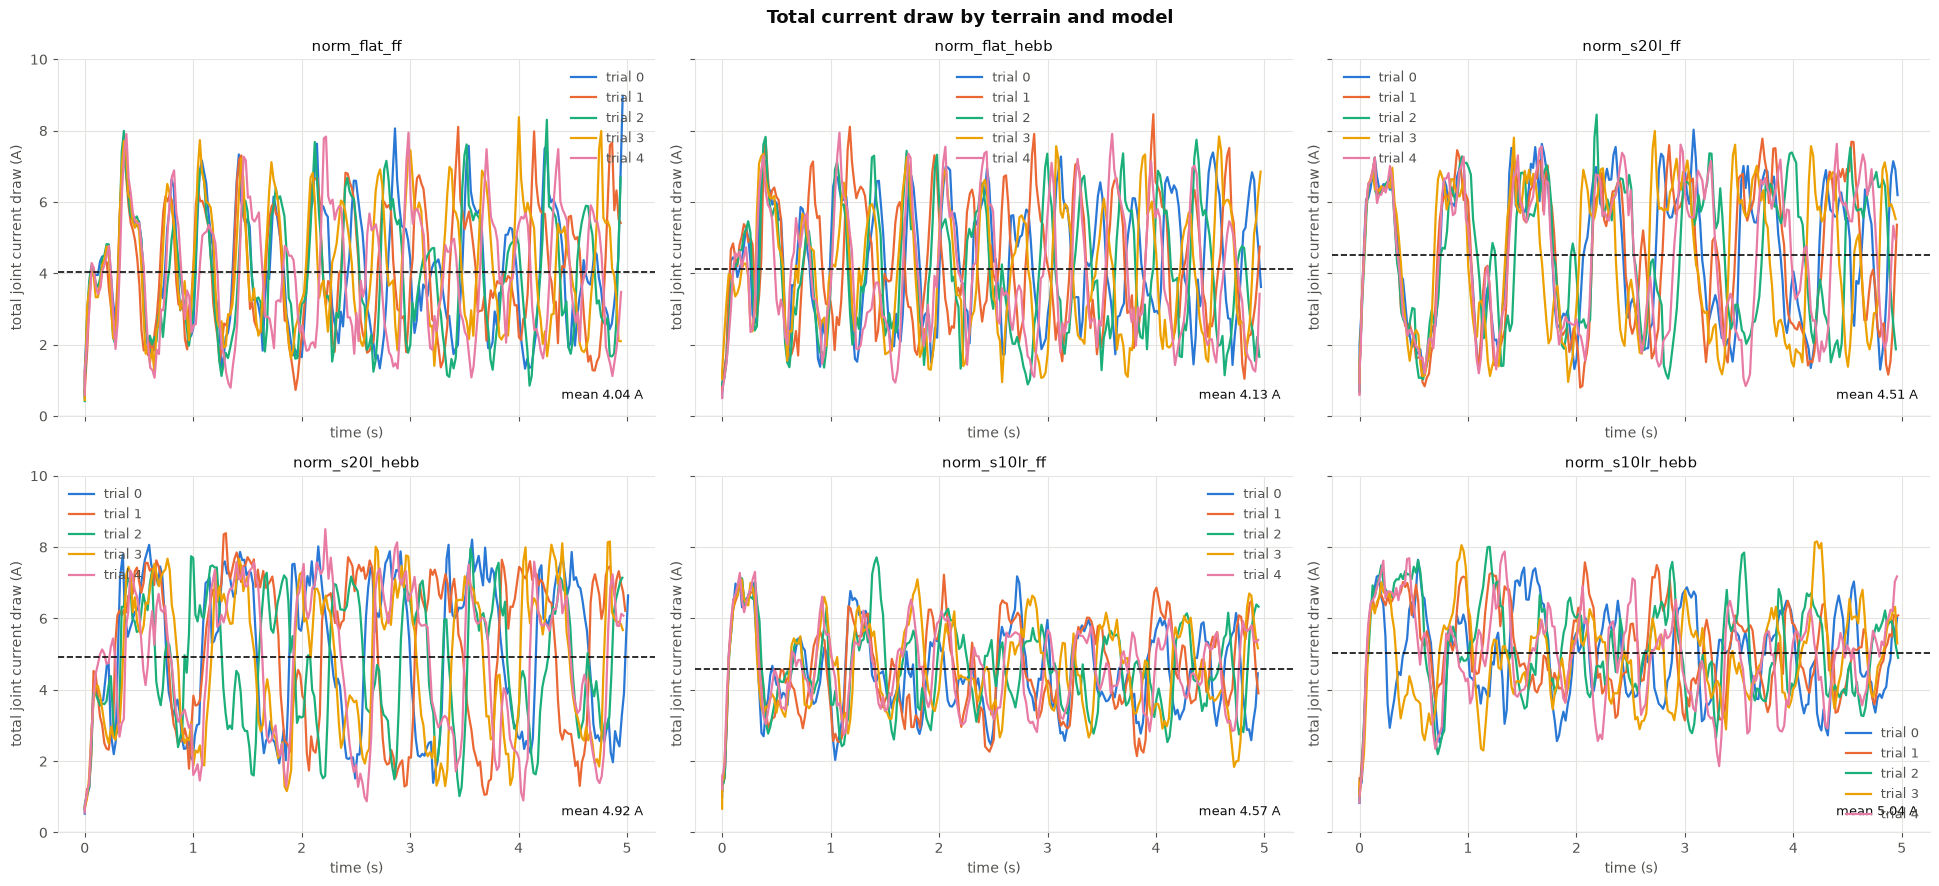

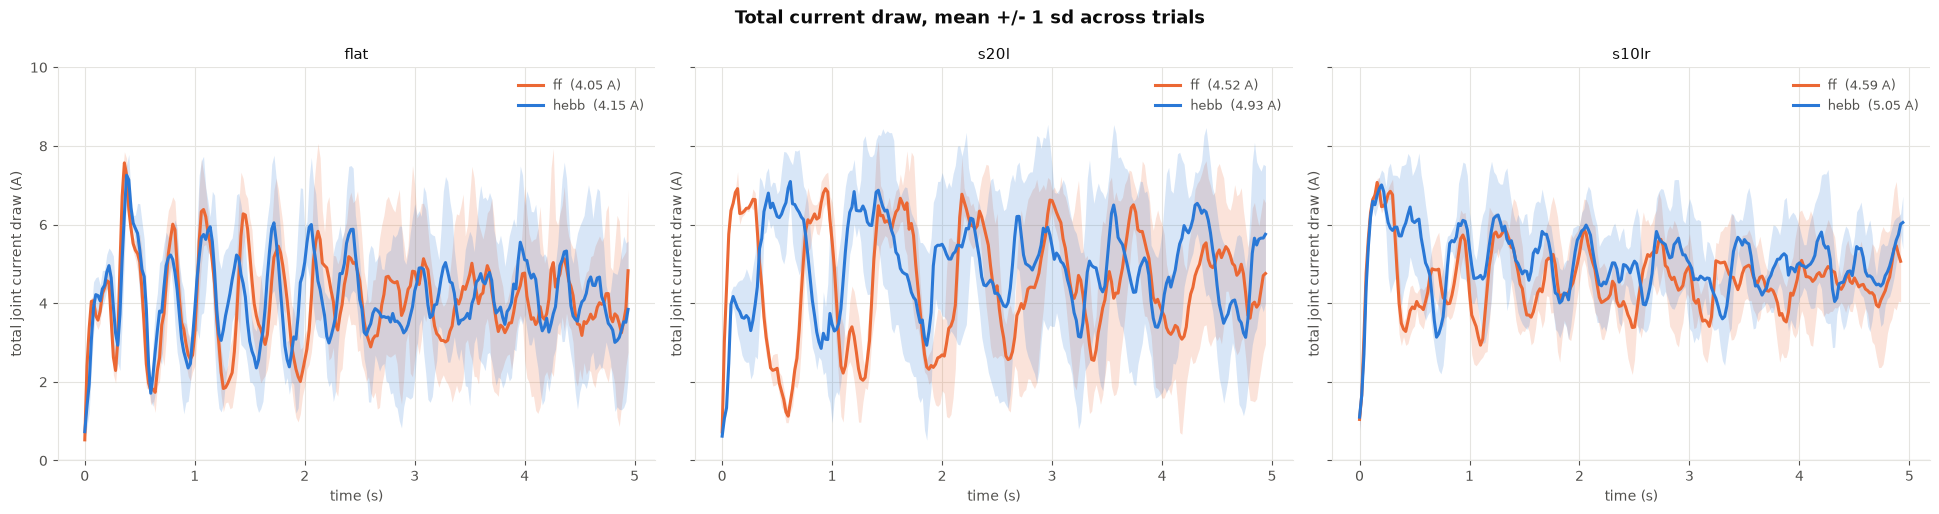

In [39]:
C_LABEL, C_LIM = 'total joint current draw (A)', (0, 10)
grid_panels(cur, C_LABEL, 'Total current draw by terrain and model',
            C_LIM, fmt='{:.2f} A')
compare_models(cur, C_LABEL, 'Total current draw, mean +/- 1 sd across trials',
               C_LIM, fmt='{:.2f} A')

## Distance & CoT (max-distance criteria)

In [40]:
# CoT normalized by the same max-distance criterion as `max_forward_distance`
# above (farthest forward reach), ported from optitrack_cot.ipynb.
GECKO_MASS = 2.45  # kg
TORQUE_CONSTANT = 0.5494505495
IDLE_CURRENT = 0.0
RAW_TO_RPM = 0.229
RPM_TO_RADPS = 2 * np.pi / 60

def calculate_cot(trial, mass, distance):
    current = (np.array(trial['current']) * RAW_TO_CURRENT) / 1000.0  # A
    torque = (current - IDLE_CURRENT) / TORQUE_CONSTANT  # N*m
    radps = np.array(trial['vel']) * RAW_TO_RPM * RPM_TO_RADPS  # rad/s
    power = np.abs(torque * radps)  # W
    energy = np.sum(np.sum(power, axis=1) * np.array(trial['dt']))  # J
    return energy / (mass * 9.81 * distance)  # J/kg/m

cot = {name: np.array([calculate_cot(raw[name][i], GECKO_MASS, max_forward_distance[name][i])
                        for i in range(len(raw[name]))])
       for name in runs}

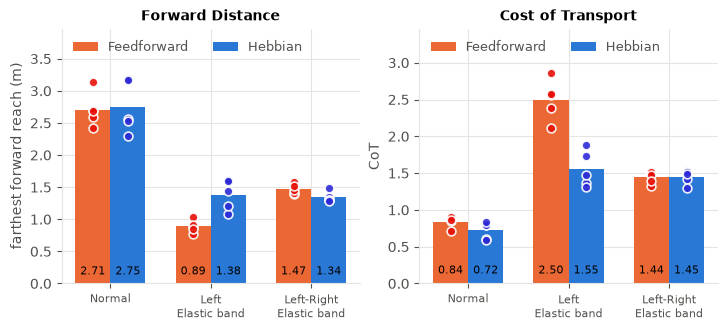

In [47]:
IEEE_TWO_COL_WIDTH = 7.16  # inches, full double-column width (IEEEtran \textwidth)

def _bar_panel(ax, groups, case, ylabel, title, mean_pos=0.1):
    n_trials = len(next(iter(groups.values()))[0])
    x = np.arange(len(case))
    width = 0.35
    for i, (label, arrs) in enumerate(groups.items()):
        means, halfwidths = zip(*(mean_ci95(a) for a in arrs))
        offset = (i - (len(groups) - 1) / 2) * width
        ax.bar(x + offset, means, width, label=label, color=BAR_COLORS[label])
        for xi, m, h , a in zip(x + offset, means, halfwidths, arrs):
            ax.text(xi, mean_pos, f'{m:.2f}', ha='center', va='bottom', fontsize=8)
            ax.scatter(np.full(len(a), xi), a, color=DOT_COLORS[label],
                       alpha=0.9, s=40, edgecolors='white', linewidth=1.2, zorder=3)
    ax.set_xticks(x, case,fontsize=8)#,rotation=30)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title}',fontsize=10,fontweight='bold')
    style_ax(ax)
    top = max(m + h for arrs in groups.values() for m, h in (mean_ci95(a) for a in arrs))
    ax.set_ylim(0, top * 1.22)
    ax.legend(loc='upper left', ncols=2, frameon=False, labelcolor=INK_MUTED, fontsize=9)

def plot_distance_cot_pair(dist_groups, cot_groups, case,
                            dist_label='farthest forward reach (m)',
                            cot_label='CoT',
                            figsize=(IEEE_TWO_COL_WIDTH, 3.2)):
    """Distance and CoT side by side, one figure, IEEE double-column width."""
    fig, axs = plt.subplots(1, 2, figsize=figsize, layout='constrained')
    _bar_panel(axs[0], dist_groups, case, dist_label, 'Forward Distance')
    _bar_panel(axs[1], cot_groups, case, cot_label, 'Cost of Transport')
    plt.show()
    return fig, axs

case = ("Normal",  "Left\nElastic band" , "Left-Right\nElastic band")

dist_groups = {
    'Feedforward': [max_forward_distance["flat_ff"],   max_forward_distance["s20l_ff"],   max_forward_distance["s10lr_ff"]],
    'Hebbian':     [max_forward_distance["flat_hebb"], max_forward_distance["s20l_hebb"], max_forward_distance["s10lr_hebb"]],
}
cot_groups = {
    'Feedforward': [cot["flat_ff"],   cot["s20l_ff"],   cot["s10lr_ff"]],
    'Hebbian':     [cot["flat_hebb"], cot["s20l_hebb"], cot["s10lr_hebb"]],
}

fig , ax  = plot_distance_cot_pair(dist_groups, cot_groups, case)
fig.savefig("distance_cot.jpg" , dpi=600)

### Trajectory + Distance/CoT, combined

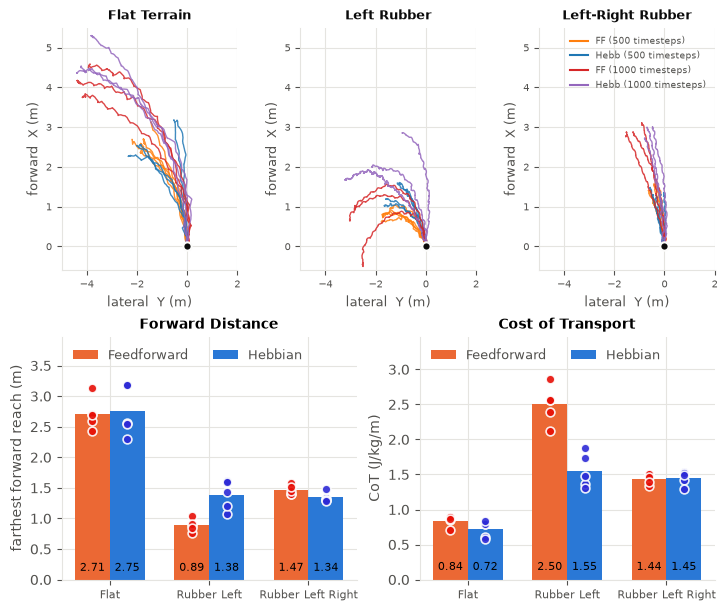

(<Figure size 716x600 with 5 Axes>,
 ([<Axes: title={'center': 'Flat Terrain'}, xlabel='lateral  Y (m)', ylabel='forward  X (m)'>,
   <Axes: title={'center': 'Left Rubber'}, xlabel='lateral  Y (m)', ylabel='forward  X (m)'>,
   <Axes: title={'center': 'Left-Right Rubber'}, xlabel='lateral  Y (m)', ylabel='forward  X (m)'>],
  [<Axes: title={'center': 'Forward Distance'}, ylabel='farthest forward reach (m)'>,
   <Axes: title={'center': 'Cost of Transport'}, ylabel='CoT (J/kg/m)'>]))

In [448]:
# Local to this cell (not the module-level `groups`, which later cells in this
# notebook reassign to unrelated dicts) so this figure can't pick up the wrong
# thing if cells are re-run out of order.
traj_groups = [
    {'label': 'FF (500 timesteps)',    'color': 'tab:orange', 'data': [norm_flat_ff,       norm_s20l_ff,       norm_s10lr_ff]},
    {'label': 'Hebb (500 timesteps)',  'color': 'tab:blue',   'data': [norm_flat_hebb,     norm_s20l_hebb,     norm_s10lr_hebb]},
    {'label': 'FF (1000 timesteps)',   'color': 'tab:red',    'data': [norm_flat_ff_extra, norm_s20l_ff_extra, norm_s10lr_ff_extra]},
    {'label': 'Hebb (1000 timesteps)', 'color': 'tab:purple', 'data': [norm_flat_hebb_extra, norm_s20l_hebb_extra, norm_s10lr_hebb_extra]},
]
traj_terrain_labels = ['Flat Terrain', 'Left Rubber', 'Left-Right Rubber']

def _traj_panel(ax, groups, terrain_i, title):
    for g in groups:
        for df in g['data'][terrain_i]:
            ax.plot(-df['z_rel'], -df['x_rel'], color=g['color'], lw=1.0, alpha=0.85)
    ax.plot(0, 0, 'o', color=INK, ms=6, mec='#fcfcfb', mew=1.5, zorder=3)
    ax.set_xlabel('lateral  Y (m)', fontsize=9)
    ax.set_ylabel('forward  X (m)', fontsize=9)
    ax.set_title(title, color=INK, fontsize=9, fontweight='bold')
    ax.set_xlim(-5.0, 2.0)
    ax.set_ylim(-0.6, 5.5)
    style_ax(ax)
    ax.tick_params(labelsize=7)
    for g in groups:
        ax.plot([], [], color=g['color'], ls='-', lw=1.5, label=g['label'])

def plot_trajectory_and_distance_cot(traj_groups, terrain_labels,
                                      dist_groups, cot_groups, case,
                                      figsize=(IEEE_TWO_COL_WIDTH, 6.0)):
    """Trajectory panels on top, distance/CoT panels below, one IEEE
    double-column-width figure. Laid out on a 6-column grid (LCM of 3 and 2)
    so a 3-panel row and a 2-panel row line up evenly."""
    fig = plt.figure(figsize=figsize, layout='constrained')
    gs = fig.add_gridspec(2, 6)

    traj_axes = [fig.add_subplot(gs[0, 2 * i:2 * i + 2]) for i in range(3)]
    for i, ax in enumerate(traj_axes):
        _traj_panel(ax, traj_groups, i, terrain_labels[i])
    traj_axes[-1].legend(frameon=False, fontsize=6.5, labelcolor=INK_MUTED, loc='upper right')

    bar_axes = [fig.add_subplot(gs[1, 3 * i:3 * i + 3]) for i in range(2)]
    _bar_panel(bar_axes[0], dist_groups, case, 'farthest forward reach (m)', 'Forward Distance')
    _bar_panel(bar_axes[1], cot_groups, case, 'CoT (J/kg/m)', 'Cost of Transport')

    plt.show()
    return fig, (traj_axes, bar_axes)

plot_trajectory_and_distance_cot(traj_groups, traj_terrain_labels, dist_groups, cot_groups, case)